Netflix is an application that keeps growing bigger and faster with its popularity, shows and content. This is an EDA or a story telling through its data along with a content-based recommendation system and a wide range of different graphs and visuals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!gdown 1D_njy5mBowKH3mBeOSfsyI3cekFbOdLa
netflix_overall=pd.read_csv('netflix_titles.csv')
netflix_overall.head()

Downloading...
From: https://drive.google.com/uc?id=1D_njy5mBowKH3mBeOSfsyI3cekFbOdLa
To: /content/netflix_titles.csv
100% 3.40M/3.40M [00:00<00:00, 78.3MB/s]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
netflix_overall.count()

,0
show_id,8807
type,8807
title,8807
director,6173
cast,7982
country,7976
date_added,8797
release_year,8807
rating,8803
duration,8804


In [4]:
netflix_overall.shape

(8807, 12)

In [5]:
netflix_shows=netflix_overall[netflix_overall['type']=='TV Show']

In [6]:
netflix_movies=netflix_overall[netflix_overall['type']=='Movie']

In [7]:
netflix_overall.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

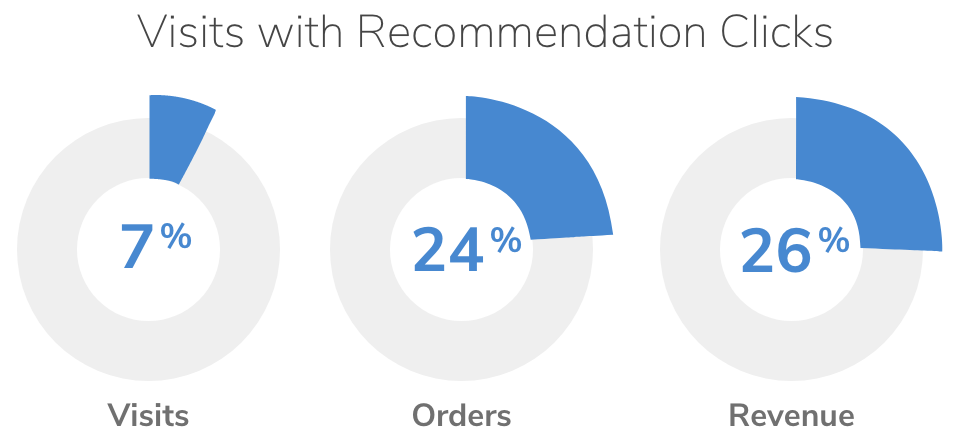

Countplot of Movies vs TV shows

<ipython-input-8-0a697f04f25a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="type", data=netflix_overall, palette="Set2")


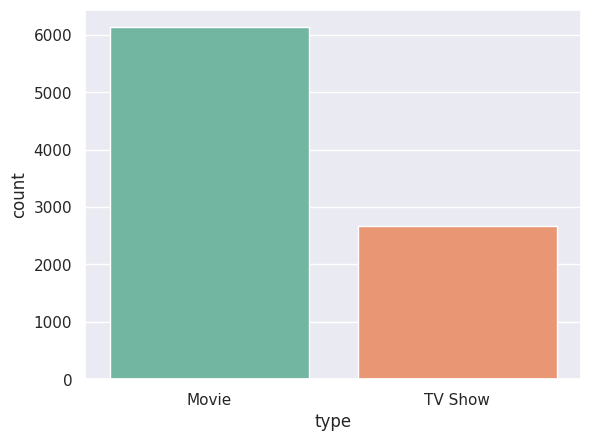

In [8]:
sns.set(style="darkgrid")
ax = sns.countplot(x="type", data=netflix_overall, palette="Set2")

It is evident that there are more Movies on Netflix than TV shows.

##If a producer wants to release some content, which month must he do so?( Month when least amount of content is added)

In [9]:
netflix_date = netflix_shows[['date_added']].dropna()
netflix_date.head()

,date_added
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"
5,"September 24, 2021"


In [10]:
netflix_date = netflix_shows[['date_added']].dropna()
netflix_date.head()

,date_added
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"
5,"September 24, 2021"


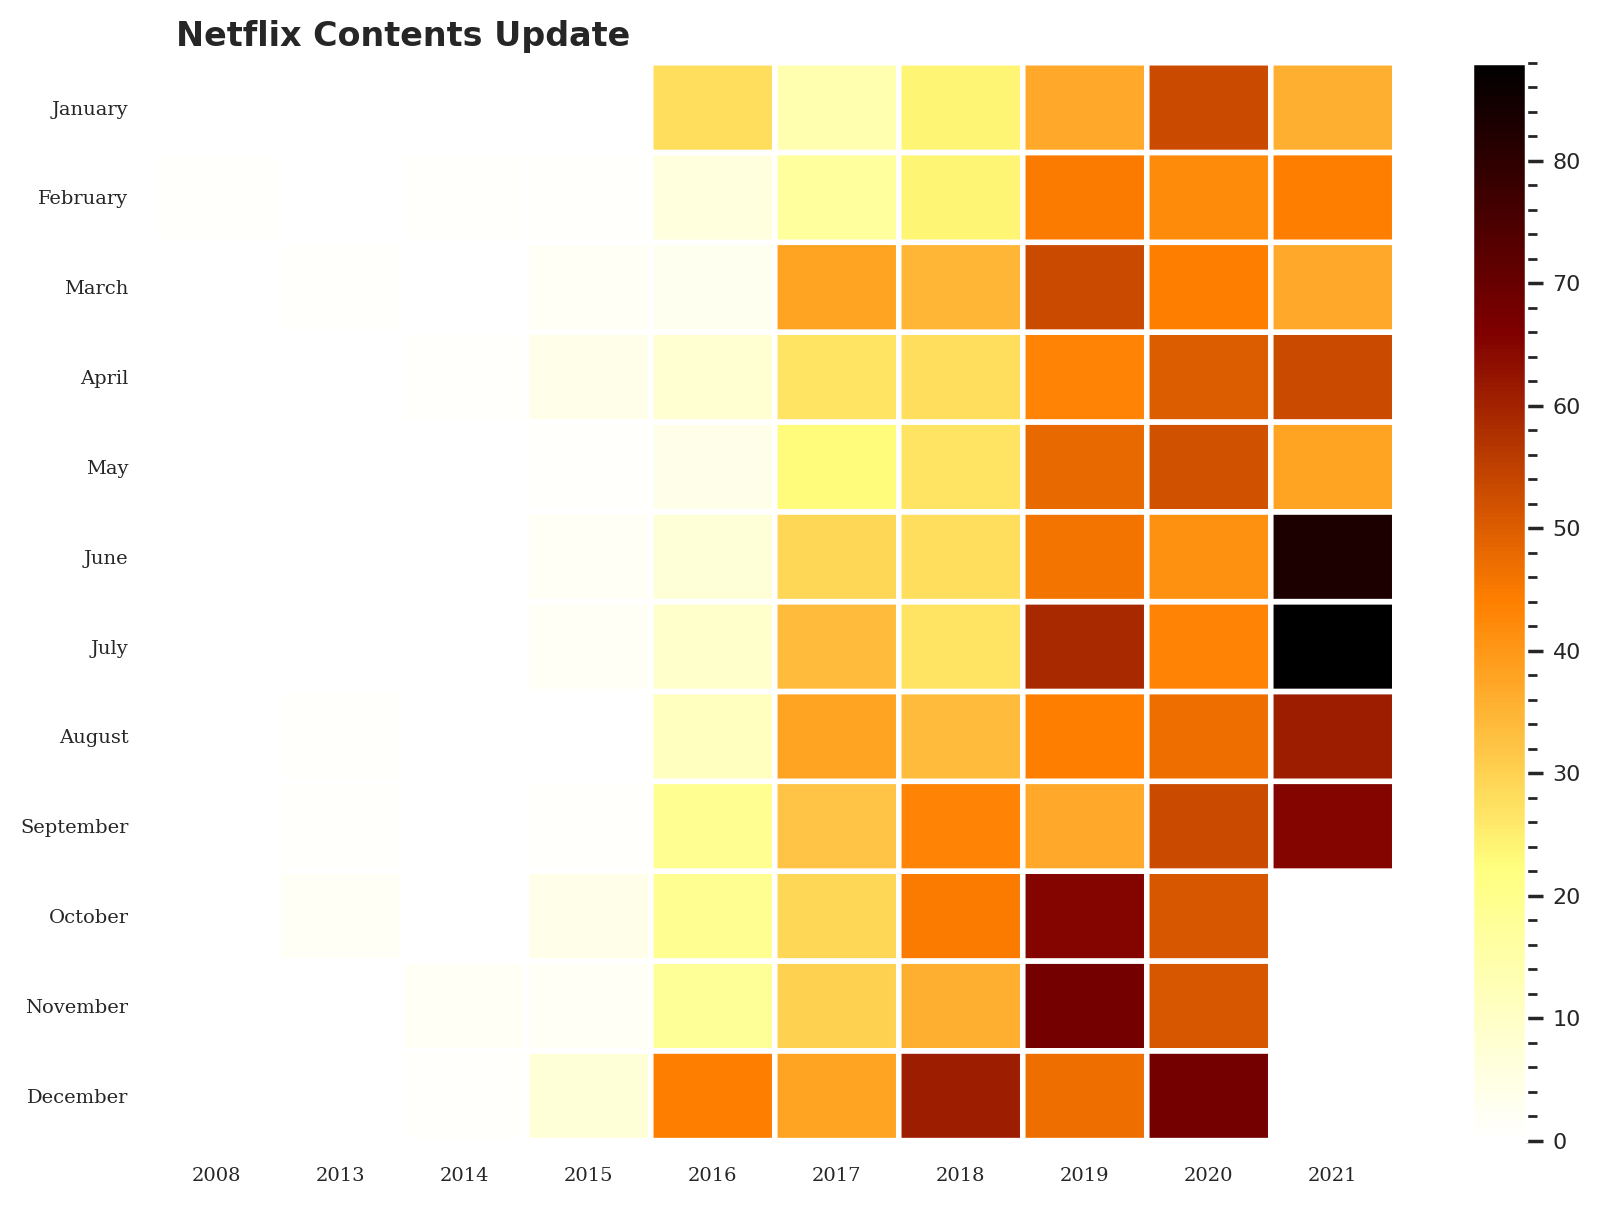

In [11]:
netflix_date['year'] = netflix_date['date_added'].apply(lambda x : x.split(', ')[-1]) #Creating the 'year' column within the same dataframe
netflix_date['month'] = netflix_date['date_added'].apply(lambda x : x.lstrip().split(' ')[0]) #Creating the 'month' column within the same dataframe
netflix_date.head()


month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'][::-1]
df = netflix_date.groupby('year')['month'].value_counts().unstack().fillna(0)[month_order].T # Now the groupby operation can find the 'year' column
plt.figure(figsize=(10, 7), dpi=200)
plt.pcolor(df, cmap='afmhot_r', edgecolors='white', linewidths=2) # heatmap
plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, fontsize=7, fontfamily='serif')
plt.yticks(np.arange(0.5, len(df.index), 1), df.index, fontsize=7, fontfamily='serif')

plt.title('Netflix Contents Update', fontsize=12, fontfamily='calibri', fontweight='bold', position=(0.20, 1.0+0.02))
cbar = plt.colorbar()

cbar.ax.tick_params(labelsize=8)
cbar.ax.minorticks_on()
plt.show()

If the latest year 2019 is considered, January and December were the months when comparatively much less content was released.Therefore, these months may be a good choice for the success of a new release!

##Movie Ratings Analysis

<ipython-input-12-6441c0d408e2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="rating", data=netflix_movies, palette="Set2", order=netflix_movies['rating'].value_counts().index[0:15])


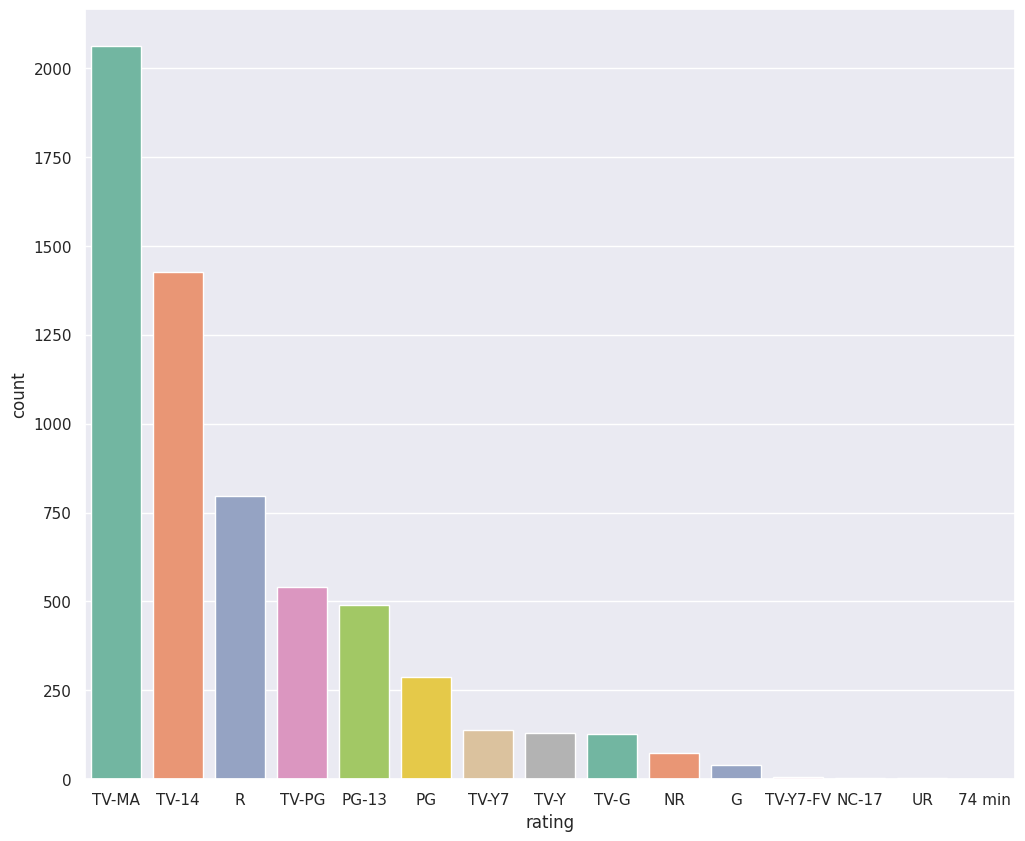

In [12]:
plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="rating", data=netflix_movies, palette="Set2", order=netflix_movies['rating'].value_counts().index[0:15])

The largest count of movies are made with the 'TV-MA' rating."TV-MA" is a rating assigned by the TV Parental Guidelines to a television program that was designed for mature audiences only.

Second largest is the 'TV-14' stands for content that may be inappropriate for children younger than 14 years of age.

Third largest is the very popular 'R' rating.An R-rated film is a film that has been assessed as having material which may be unsuitable for children under the age of 17 by the Motion Picture Association of America; the MPAA writes "Under 17 requires accompanying parent or adult guardian".

##Analysing IMDB ratings to get top rated movies on Netflix

In [13]:
!gdown 1X_7FRvat-y4IFhKGVYIYx59ZL_Kpj12j
!gdown 1p3W6pX3dzFj8AO1ssP1Qs7aBB3DxC45y
imdb_ratings=pd.read_csv('IMDb ratings.csv')
print(imdb_ratings.columns)

Downloading...
From: https://drive.google.com/uc?id=1X_7FRvat-y4IFhKGVYIYx59ZL_Kpj12j
To: /content/IMDb ratings.csv
100% 17.4M/17.4M [00:00<00:00, 21.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1p3W6pX3dzFj8AO1ssP1Qs7aBB3DxC45y
To: /content/IMDb movies.csv
100% 47.8M/47.8M [00:00<00:00, 56.2MB/s]
Index(['imdb_title_id', 'weighted_average_vote', 'total_votes', 'mean_vote',
       'median_vote', 'votes_10', 'votes_9', 'votes_8', 'votes_7', 'votes_6',
       'votes_5', 'votes_4', 'votes_3', 'votes_2', 'votes_1',
       'allgenders_0age_avg_vote', 'allgenders_0age_votes',
       'allgenders_18age_avg_vote', 'allgenders_18age_votes',
       'allgenders_30age_avg_vote', 'allgenders_30age_votes',
       'allgenders_45age_avg_vote', 'allgenders_45age_votes',
       'males_allages_avg_vote', 'males_allages_votes', 'males_0age_avg_vote',
       'males_0age_votes', 'males_18age_avg_vote', 'males_18age_votes',
       'males_30age_avg_vote', 'males_30age_votes', 'males_45age_avg_vote

In [14]:
imdb_ratings = imdb_ratings[['weighted_average_vote']]
imdb_titles=pd.read_csv('IMDb movies.csv', usecols=['title','year','genre'])
ratings = pd.DataFrame({'Title':imdb_titles.title,
                    'Release Year':imdb_titles.year,
                    'Rating': imdb_ratings.weighted_average_vote,
                    'Genre':imdb_titles.genre})
ratings.drop_duplicates(subset=['Title','Release Year','Rating'], inplace=True)
ratings.shape

<ipython-input-14-a759e7500cc8>:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  imdb_titles=pd.read_csv('IMDb movies.csv', usecols=['title','year','genre'])


(85852, 4)

In [15]:
ratings.head()

,Title,Release Year,Rating,Genre
0,Miss Jerry,1894,5.9,Romance
1,The Story of the Kelly Gang,1906,6.1,"Biography, Crime, Drama"
2,Den sorte drøm,1911,5.8,Drama
3,Cleopatra,1912,5.2,"Drama, History"
4,L'Inferno,1911,7.0,"Adventure, Drama, Fantasy"


Performing inner join on the ratings dataset and netflix dataset to get the content that has both ratings on IMDB and are available on Netflix.

In [16]:
ratings.dropna()
joint_data=ratings.merge(netflix_overall,left_on='Title',right_on='title',how='inner')
joint_data=joint_data.sort_values(by='Rating', ascending=False)

In [17]:
joint_data.head()

,Title,Release Year,Rating,Genre,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
989,Breakout,2019,9.0,"Adventure, Comedy, Drama",s5394,TV Show,Breakout,NaN,"Jeanette Aw, Elvin Ng, Zhou Ying, Christopher ...",NaN,"July 1, 2017",2010,TV-14,1 Season,"International TV Shows, TV Dramas",After losing her family in a suspicious car cr...
2657,Innocent,2017,9.0,Comedy,s4175,TV Show,Innocent,Seren Yüce,"Ali Atay, Haluk Bilginer, Nur Sürer, Okan Yala...",Turkey,"January 23, 2019",2017,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","In a peaceful, rustic town, a retired officer ..."
223,Schindler's List,1993,8.9,"Biography, Drama, History",s7958,Movie,Schindler's List,Steven Spielberg,"Liam Neeson, Ben Kingsley, Ralph Fiennes, Caro...",United States,"April 1, 2018",1993,R,195 min,"Classic Movies, Dramas",Oskar Schindler becomes an unlikely humanitari...
236,Pulp Fiction,1994,8.9,"Crime, Drama",s7803,Movie,Pulp Fiction,Quentin Tarantino,"John Travolta, Samuel L. Jackson, Uma Thurman,...",United States,"January 1, 2019",1994,R,154 min,"Classic Movies, Cult Movies, Dramas",This stylized crime caper weaves together stor...
1128,Inception,2010,8.8,"Action, Adventure, Sci-Fi",s341,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...","United States, United Kingdom","August 1, 2021",2010,PG-13,148 min,"Action & Adventure, Sci-Fi & Fantasy, Thrillers",A troubled thief who extracts secrets from peo...


Top rated 10 movies on Netflix are:

In [18]:
import plotly.express as px
top_rated=joint_data[0:10]
fig =px.sunburst(
    top_rated,
    path=['title','country'],
    values='Rating',
    color='Rating')
fig.show()

Countries with highest rated content.

In [19]:
country_count=joint_data['country'].value_counts().sort_values(ascending=False)
country_count=pd.DataFrame(country_count)
topcountries=country_count[0:11]
topcountries

,count
country,
United States,865
India,718
United Kingdom,119
Canada,57
Philippines,50
Spain,41
Indonesia,38
South Korea,38
France,37


In [20]:
data = dict(
    number=[1063,619,135,60,44,41,40,40,38,35],
    country=["United States", "India", "United Kingdom", "Canada", "Spain",'Turkey','Philippines','France','South Korea','Australia'])
fig = px.funnel(data, x='number', y='country')
fig.show()

Year wise analysis

<ipython-input-21-00257fe57256>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




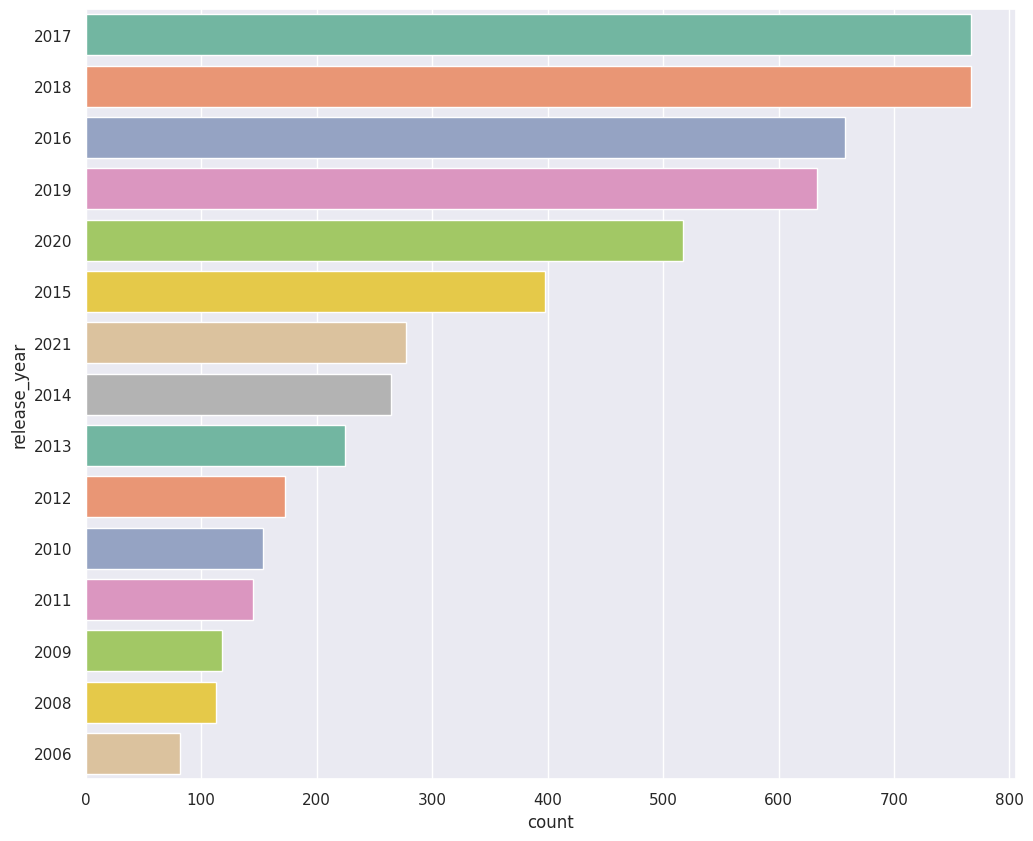

In [21]:
plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(y="release_year", data=netflix_movies, palette="Set2", order=netflix_movies['release_year'].value_counts().index[0:15])

So, 2017 was the year when most of the movies were released.

In [22]:
netflix_movies['country'].value_counts(normalize=True)

,proportion
country,
United States,0.361624
India,0.156914
United Kingdom,0.036198
Canada,0.021437
Spain,0.017044
...,...
"Germany, Italy",0.000176
"Taiwan, China, France, United States",0.000176
"Philippines, Singapore",0.000176


In [23]:
countries={}
netflix_movies['country']=netflix_movies['country'].fillna('Unknown')
cou=list(netflix_movies['country'])
for i in cou:
    #print(i)
    i=list(i.split(','))
    if len(i)==1:
        if i in list(countries.keys()):
            countries[i]+=1
        else:
            countries[i[0]]=1
    else:
        for j in i:
            if j in list(countries.keys()):
                countries[j]+=1
            else:
                countries[j]=1

<ipython-input-23-05759bc2aa29>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [24]:
countries_fin={}
for country,no in countries.items():
    country=country.replace(' ','')
    if country in list(countries_fin.keys()):
        countries_fin[country]+=no
    else:
        countries_fin[country]=no

countries_fin={k: v for k, v in sorted(countries_fin.items(), key=lambda item: item[1], reverse= True)}

TOP 10 MOVIE CONTENT CREATING COUNTRIES

<ipython-input-25-8892c2647d47>:3: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



[Text(0, 0, 'UnitedStates'),
 Text(1, 0, 'France'),
 Text(2, 0, 'UnitedKingdom'),
 Text(3, 0, 'Canada'),
 Text(4, 0, 'Germany'),
 Text(5, 0, 'Belgium'),
 Text(6, 0, 'China'),
 Text(7, 0, 'Spain'),
 Text(8, 0, 'Japan'),
 Text(9, 0, 'India')]

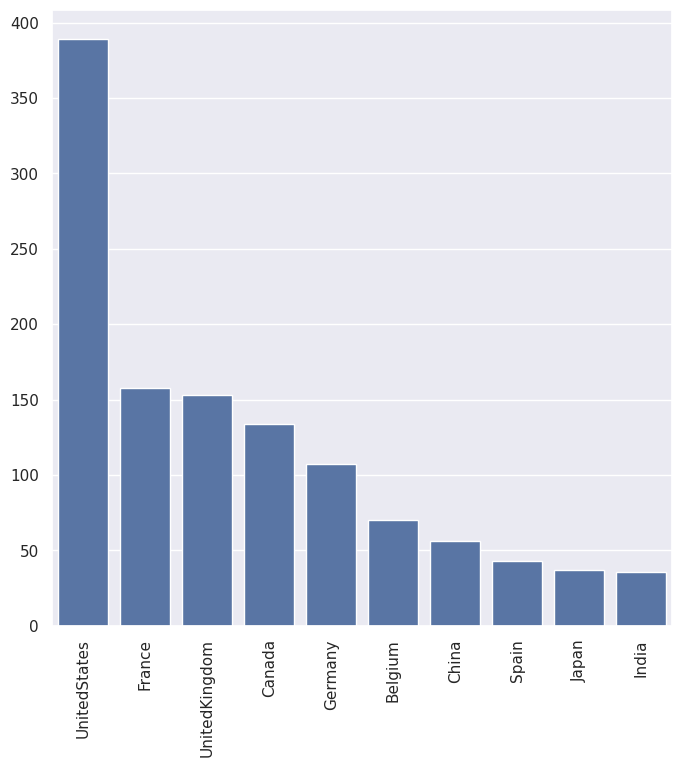

In [25]:
plt.figure(figsize=(8,8))
ax = sns.barplot(x=list(countries_fin.keys())[0:10],y=list(countries_fin.values())[0:10])
ax.set_xticklabels(list(countries_fin.keys())[0:10],rotation = 90)

Analysis of duration of movies

In [27]:
netflix_movies['duration'] = netflix_movies['duration'].str.replace(' min', '')
netflix_movies['duration'] = pd.to_numeric(netflix_movies['duration'], errors='coerce')
netflix_movies['duration'] = netflix_movies['duration'].fillna(0).astype(int)

<ipython-input-27-81005af9dba4>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-27-81005af9dba4>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-27-81005af9dba4>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<ipython-input-28-a6264ef750d3>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



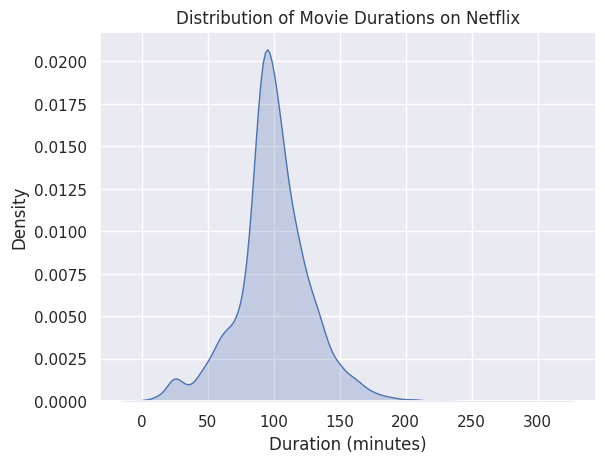

In [28]:
netflix_movies['duration'] = pd.to_numeric(netflix_movies['duration'], errors='coerce')

sns.set(style="darkgrid")
sns.kdeplot(data=netflix_movies['duration'], fill=True)

plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Density")
plt.show()

So, a good amount of movies on Netflix are among the duration of 75-120 mins. It is acceptable considering the fact that a fair amount of the audience cannot watch a 3 hour movie in one sitting. Can you? :p

In [29]:
netflix_movies['listed_in'].unique()

array(['Documentaries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'Comedies, Dramas', 'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'Documentaries, International Movies', 'Thrillers',
       'Comedies, International Movies',
       'Comedies, International Movies, Romantic Movies',
       'Comedies, International Movies, Music & Musicals', 'Comedies',
       'Horror Movies, Sci-Fi & Fantasy',
       'Dramas, International Movies, Thrillers',
       'Action & Adventure, Dramas, International Movies',
       'Action & Adventure, Dramas',
       'Action & Adventure, Classic Movies, Dramas',
       'Dramas, Horror Movies, Thrillers',
       'Action & Adventure, Horror Movies, Thrillers',
       'Action & Adventure', 'Dramas, Thrillers',
       'Action & Adventure, Anime Features, International Movies',
       'Documentaries, International Movies, Sports Movies',
       'Comedies, Dramas, International

WordCloud for Genres

In [36]:
print(netflix_movies['listed_in'].isnull().sum())
print(netflix_movies['listed_in'].head())

0
0                                        Documentaries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
9                                     Comedies, Dramas
12                        Dramas, International Movies
Name: listed_in, dtype: object


In [37]:
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import gdown
import io
from collections import Counter

# Ensure no missing values in 'listed_in'
netflix_movies = netflix_movies[netflix_movies['listed_in'].notnull()]

# Clean and collect genres
genres = list(netflix_movies['listed_in'])
gen = []

for i in genres:
    i = list(i.split(','))
    for j in i:
        gen.append(j.strip().replace(' ', ""))  # Remove extra spaces

# Create text string
text_string = " ".join(gen)
print(f"Text preview: {text_string[:100]}")
print(f"Total words: {len(text_string.split())}")

# Exit early if no words
if not text_string.strip():
    raise ValueError("Genre text string is empty after cleaning.")

# Download the image mask from Google Drive
file_id = "1EuxD5uqjdQjUWHMfngSNmKtND0M4Y6gw"
url = f"https://drive.google.com/uc?id={file_id}"
response = gdown.download(url, quiet=True, fuzzy=True)

Text preview: Documentaries Children&FamilyMovies Dramas IndependentMovies InternationalMovies Comedies Dramas Dra
Total words: 13190


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


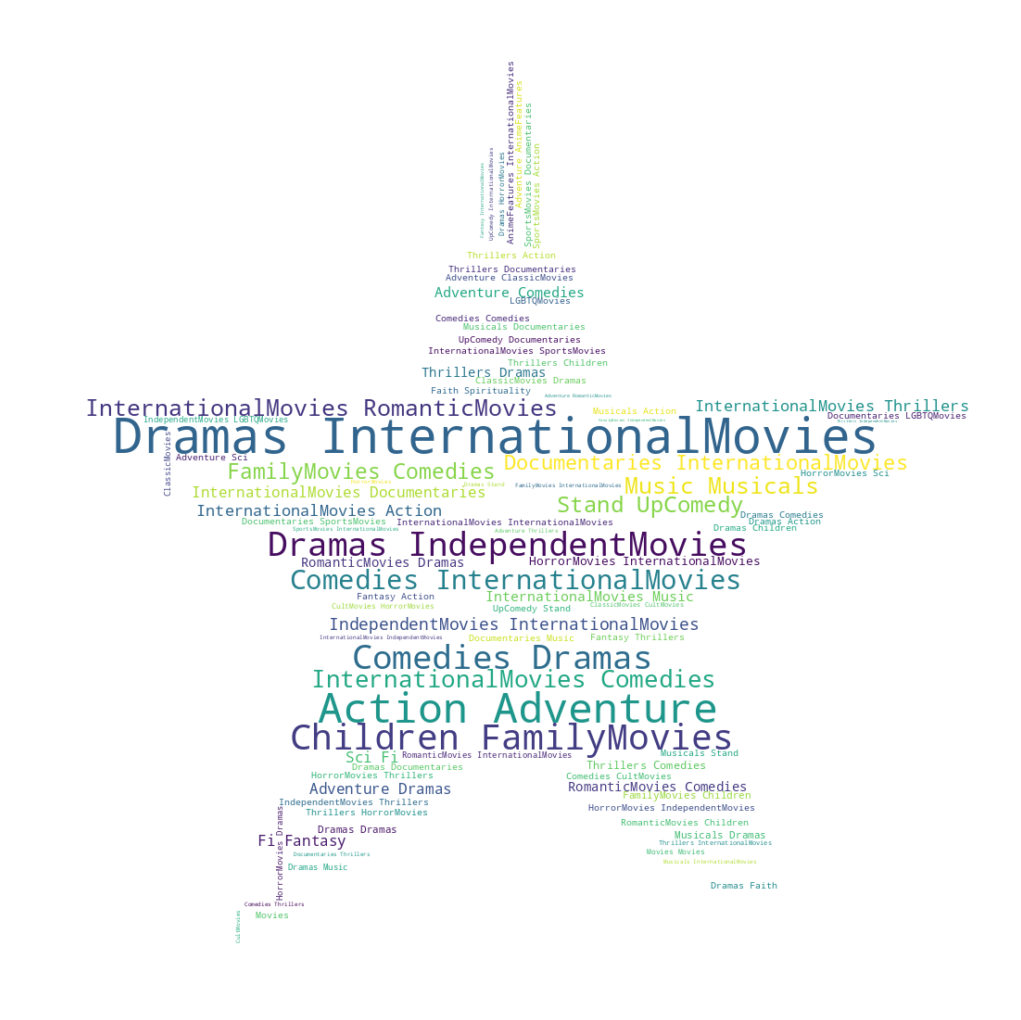

In [38]:
import nltk
nltk.download('stopwords')
# Download the file and read its content as bytes
response = gdown.download(url, quiet=True, fuzzy=True)
with open(response, 'rb') as f: # Open the file in binary read mode ('rb')
    image_bytes = f.read() # Read the file content as bytes

image = Image.open(io.BytesIO(image_bytes)) # Open image from bytes

# assigning shape to the word cloud
mask = np.array(image) # Use the Image object
text_string = " ".join(gen)  # NOT set(gen) — keep repetitions for frequency
stopwords = set(STOPWORDS)
stopwords.update(["TV", "Show", "Series"])  # example custom stopwords

wordcloud = WordCloud(
    max_words=1000000,
    background_color="white",
    mask=mask,
    stopwords=stopwords
).generate(text_string)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Lollipop plot of Genres vs their count on Netflix

<ipython-input-39-2b8296a387ff>:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



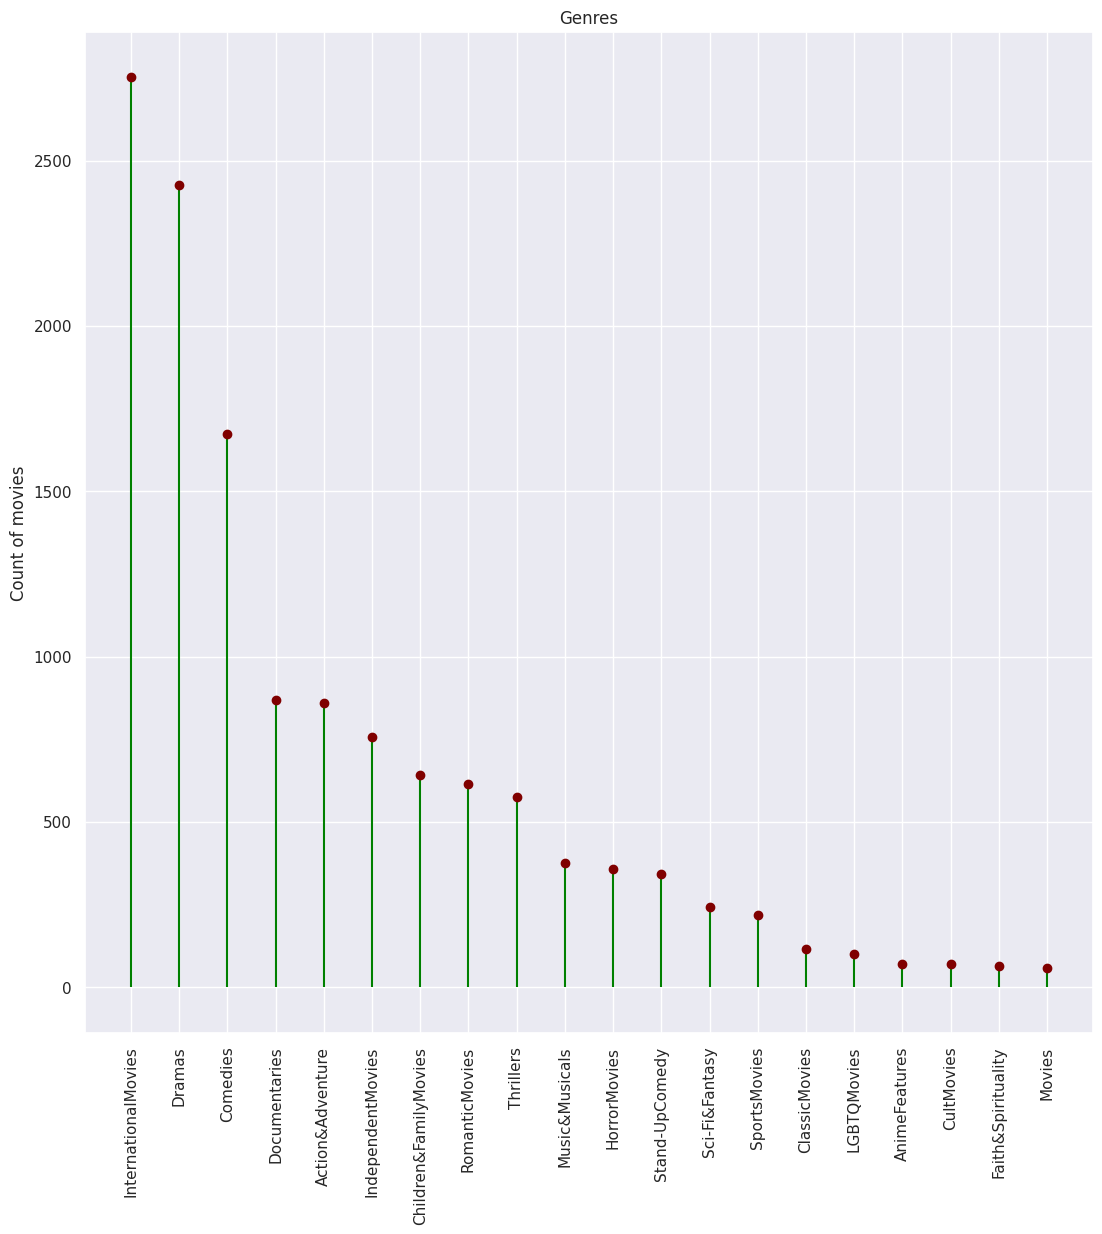

<Figure size 1000x1000 with 0 Axes>

In [39]:
g={k: v for k, v in sorted(g.items(), key=lambda item: item[1], reverse= True)}


fig, ax = plt.subplots()

fig = plt.figure(figsize = (10, 10))
x=list(g.keys())
y=list(g.values())
ax.vlines(x, ymin=0, ymax=y, color='green')
ax.plot(x,y, "o", color='maroon')
ax.set_xticklabels(x, rotation = 90)
ax.set_ylabel("Count of movies")
# set a title
ax.set_title("Genres");


Therefore, it is clear that international movies, dramas and comedies are the top three genres that have the highest amount of content on Netflix.

##Analysis of TV SERIES on Netflix

In [40]:
countries1={}
netflix_shows['country']=netflix_shows['country'].fillna('Unknown')
cou1=list(netflix_shows['country'])
for i in cou1:
    #print(i)
    i=list(i.split(','))
    if len(i)==1:
        if i in list(countries1.keys()):
            countries1[i]+=1
        else:
            countries1[i[0]]=1
    else:
        for j in i:
            if j in list(countries1.keys()):
                countries1[j]+=1
            else:
                countries1[j]=1

<ipython-input-40-af70cc212816>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [41]:
countries_fin1={}
for country,no in countries1.items():
    country=country.replace(' ','')
    if country in list(countries_fin1.keys()):
        countries_fin1[country]+=no
    else:
        countries_fin1[country]=no

countries_fin1={k: v for k, v in sorted(countries_fin1.items(), key=lambda item: item[1], reverse= True)}

Countries creating maximum content

Text(0, 0.5, 'Arrival delay (in minutes)')

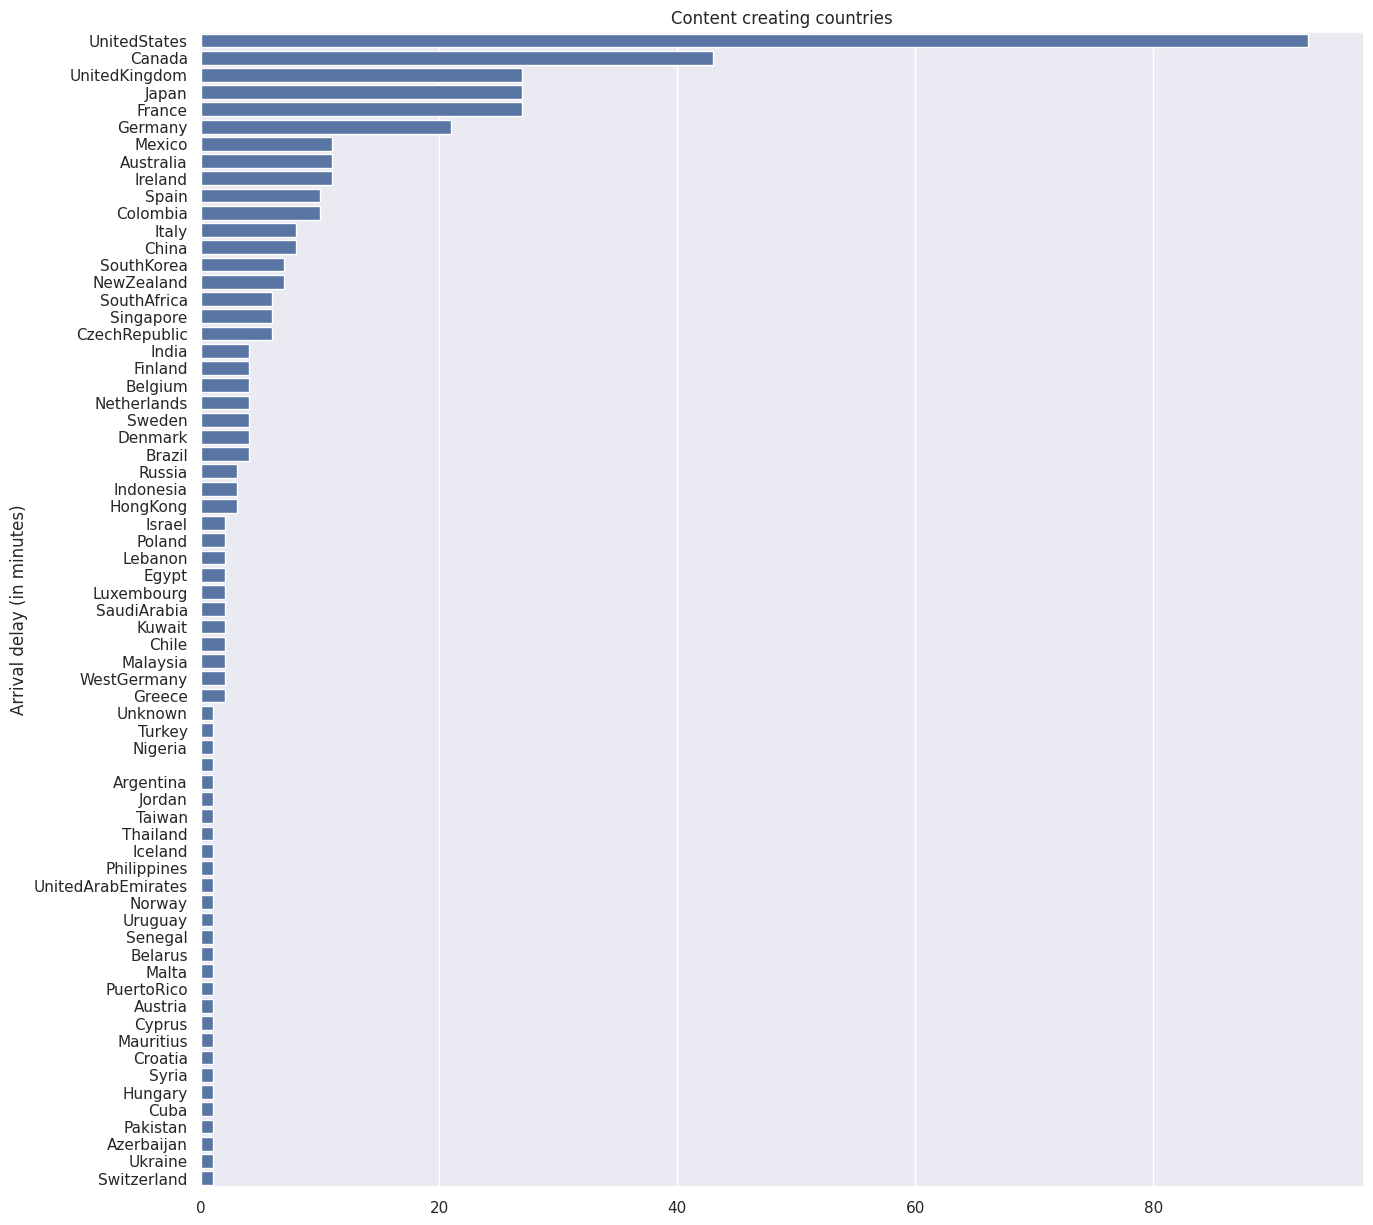

In [42]:
# Set the width and height of the figure
plt.figure(figsize=(15,15))

# Add title
plt.title("Content creating countries")

# Bar chart showing average arrival delay for Spirit Airlines flights by month
sns.barplot(y=list(countries_fin1.keys()), x=list(countries_fin1.values()))

# Add label for vertical axis
plt.ylabel("Arrival delay (in minutes)")

Naturally, United States has the most content that is created on netflix in the tv series category.

In [43]:
features=['title','duration']
durations= netflix_shows[features]

durations['no_of_seasons']=durations['duration'].str.replace(' Season','')

#durations['no_of_seasons']=durations['no_of_seasons'].astype(str).astype(int)
durations['no_of_seasons']=durations['no_of_seasons'].str.replace('s','')

<ipython-input-43-dfedf649a3e0>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-43-dfedf649a3e0>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [44]:
durations['no_of_seasons']=durations['no_of_seasons'].astype(str).astype(int)
durations['no_of_seasons'].head()

<ipython-input-44-cc53a5294f65>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,no_of_seasons
1,2
2,1
3,1
4,2
5,1


In [45]:
t=['title','no_of_seasons']
top=durations[t]

top=top.sort_values(by='no_of_seasons', ascending=False)

<Axes: xlabel='title'>

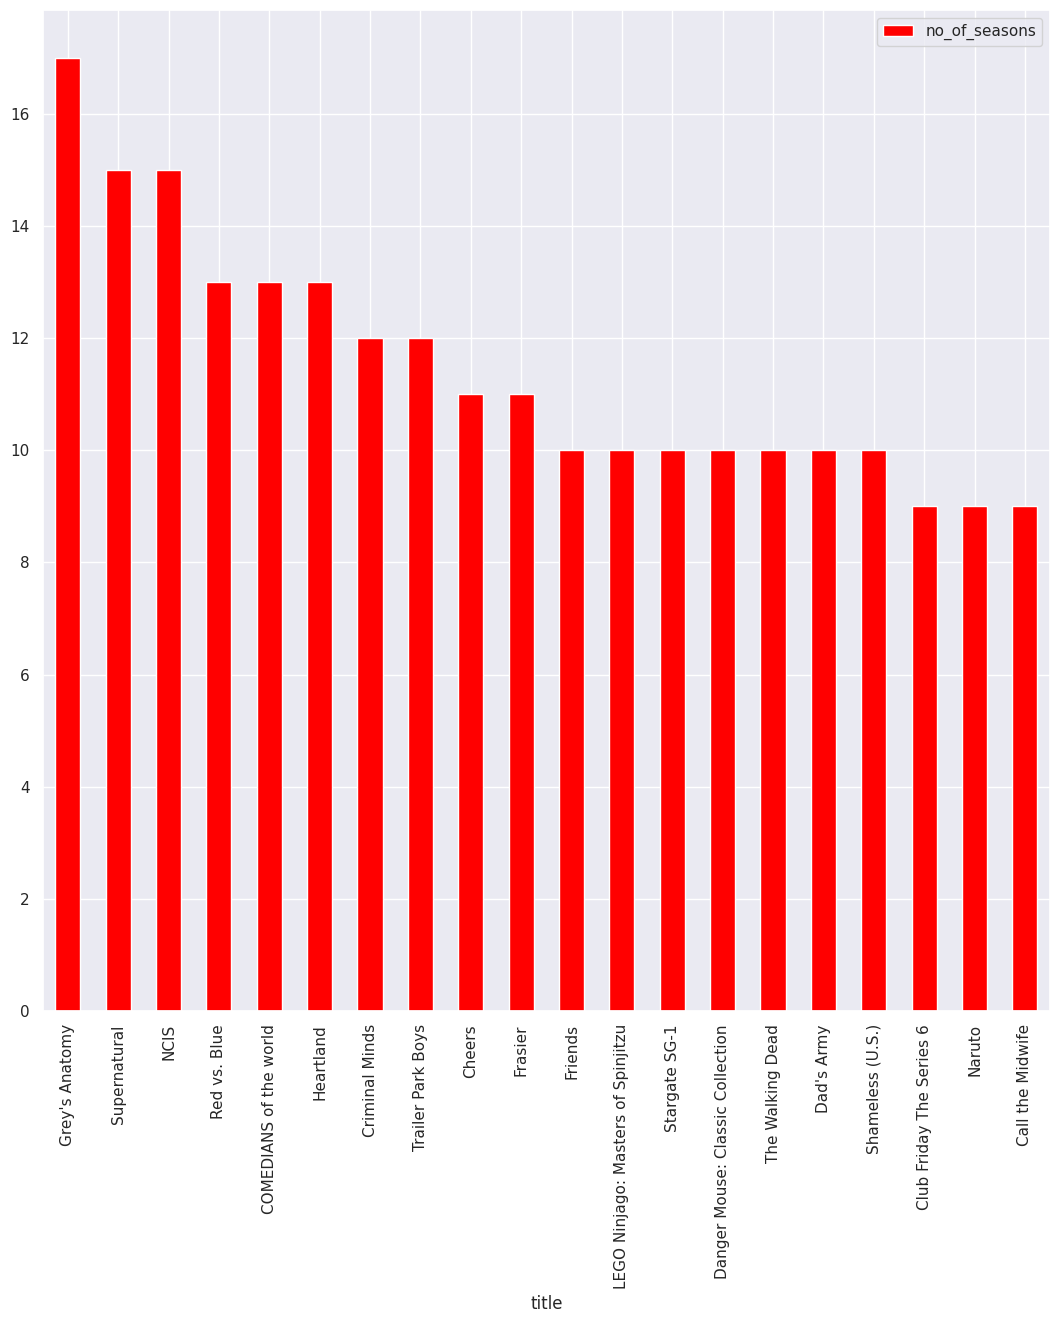

In [46]:
top20=top[0:20]
top20.plot(kind='bar',x='title',y='no_of_seasons', color='red')

Thus, NCIS, Grey's Anatomy and Supernatural are amongst the tv series that have highest number of seasons.

Lowest number of seasons

In [47]:
bottom=top.sort_values(by='no_of_seasons')
bottom=bottom[20:50]

import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(header=dict(values=['Title', 'No of seasons']),
                 cells=dict(values=[bottom['title'],bottom['no_of_seasons']],fill_color='lavender'))
                     ])
fig.show()

These are some binge-worthy shows that are short and have only one season.

Word Cloud for Genres

A word cloud is an image made of words that together resemble a cloudy shape.

Downloading...
From: https://drive.google.com/uc?id=1R-sbJavkxMNcqB172h3RLSsbn8VLXBNm
To: /content/upvote.png
100% 397k/397k [00:00<00:00, 110MB/s]


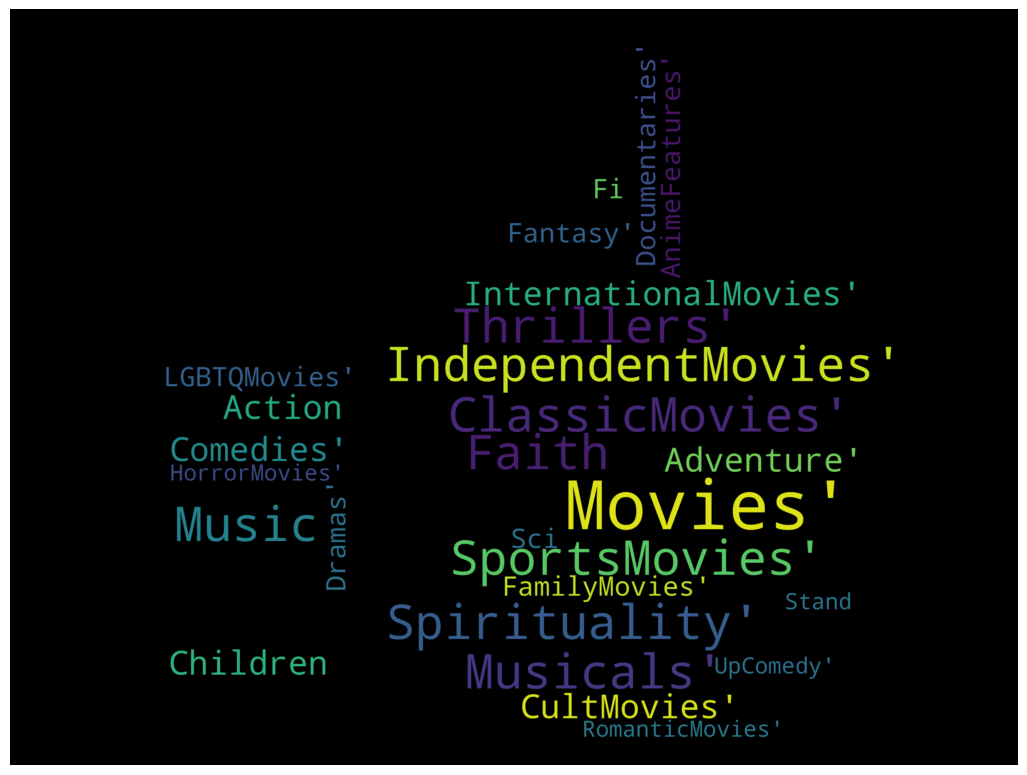

In [48]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

text = list(set(gen))
!gdown 1R-sbJavkxMNcqB172h3RLSsbn8VLXBNm
mask=np.array(Image.open('upvote.png'))
wordcloud = WordCloud(max_words=1000000,background_color="black",mask=mask).generate(str(text))
plt.rcParams['figure.figsize'] = (13, 13)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

In [49]:
us_series_data=netflix_shows[netflix_shows['country']=='United States']

In [50]:
oldest_us_series=us_series_data.sort_values(by='release_year')[0:20]

In [51]:
fig = go.Figure(data=[go.Table(header=dict(values=['Title', 'Release Year'],fill_color='paleturquoise'),
                 cells=dict(values=[oldest_us_series['title'],oldest_us_series['release_year']],fill_color='pink'))
                     ])
fig.show()

Above table shows the oldest US tv shows on Netflix.

In [52]:
newest_us_series=us_series_data.sort_values(by='release_year', ascending=False)[0:50]

In [53]:
fig = go.Figure(data=[go.Table(header=dict(values=['Title', 'Release Year'],fill_color='yellow'),
                 cells=dict(values=[newest_us_series['title'],newest_us_series['release_year']],fill_color='lavender'))
                     ])
fig.show()

The above are latest released US television shows!

Content in France

In [54]:
netflix_fr=netflix_overall[netflix_overall['country']=='France']
nannef=netflix_fr.dropna()
import plotly.express as px
fig = px.treemap(nannef, path=['country','director'],
                  color='director', hover_data=['director','title'],color_continuous_scale='Purples')
fig.show()

It is very interesting to note that the content in France is very rational. There is no director in the data who has a large number of movies. In my opinion, it shows how different directors are given a chance to showcase their talents.

In [55]:
newest_fr_series=netflix_fr.sort_values(by='release_year', ascending=False)[0:20]

In [56]:
newest_fr_series

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
91,s92,Movie,The Women and the Murderer,"Mona Achache, Patricia Tourancheau",NaN,France,"September 9, 2021",2021,TV-14,92 min,"Documentaries, International Movies",This documentary traces the capture of serial ...
273,s274,TV Show,Gone for Good,Juan Carlos Medina,"Finnegan Oldfield, Nicolas Duvauchelle, Guilla...",France,"August 13, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","Ten years after losing two loved ones, a man i..."
299,s300,Movie,The Swarm,Just Philippot,"Suliane Brahim, Sofian Khammes, Marie Narbonne...",France,"August 6, 2021",2021,TV-14,102 min,"Horror Movies, Independent Movies, Internation...",A single mother breeds locusts as high-protein...
1110,s1111,Movie,Madame Claude,Sylvie Verheyde,"Karole Rocher, Garance Marillier, Roschdy Zem,...",France,"April 2, 2021",2021,TV-MA,113 min,"Dramas, International Movies","In 1960s Paris, Madame Claude's influence exte..."
1236,s1237,Movie,Sentinelle,Julien Leclercq,"Olga Kurylenko, Marilyn Lima, Michel Nabokoff,...",France,"March 5, 2021",2021,TV-MA,81 min,"Action & Adventure, Dramas, International Movies",Transferred home after a traumatizing combat m...
1329,s1330,Movie,The Misadventures of Hedi and Cokeman,Julien Royal,"Hedi Bouchenafa, Nassim Lyes, Fred Testot, Jul...",France,"February 10, 2021",2021,TV-MA,99 min,"Comedies, International Movies","In Paris, two dysfunctional dealers use family..."
1223,s1224,TV Show,Dealer,"Ange Basterga, Nicolas Lopez","Abdramane Diakité, Mohamed Boudouh, Sébastien ...",France,"March 10, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",Tensions erupt when two filmmakers infiltrate ...
1874,s1875,Movie,Bigflo & Oli: Hip Hop Frenzy,"Bigflo & Oli, Jérémie Levypon",Bigflo & Oli,France,"October 8, 2020",2020,TV-MA,100 min,"Documentaries, International Movies, Music & M...",Go backstage with French rap duo Bigflo & Oli ...
1586,s1587,TV Show,Room 2806: The Accusation,Jalil Lespert,NaN,France,"December 7, 2020",2020,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...",This docuseries follows the 2011 sexual assaul...
1780,s1781,Movie,Rogue City,Olivier Marchal,"Lannick Gautry, Stanislas Merhar, Kaaris, Davi...",France,"October 30, 2020",2020,TV-MA,116 min,"Dramas, International Movies, Thrillers",Caught in the crosshairs of police corruption ...


In [57]:
fig = go.Figure(data=[go.Table(header=dict(values=['Title', 'Release Year']),
                 cells=dict(values=[newest_fr_series['title'],newest_fr_series['release_year']]))
                     ])
fig.show()

##Top Duration

In [58]:
topdirs=pd.value_counts(netflix_overall['duration'])
fig = go.Figure([go.Bar(x=topdirs.index, y=topdirs.values , text=topdirs.values,marker_color='indianred')])
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.show()

<ipython-input-58-cc6a7b4ad274>:1: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.



It can be inferred that having one season is the most preferred duration.

##A little interesting history

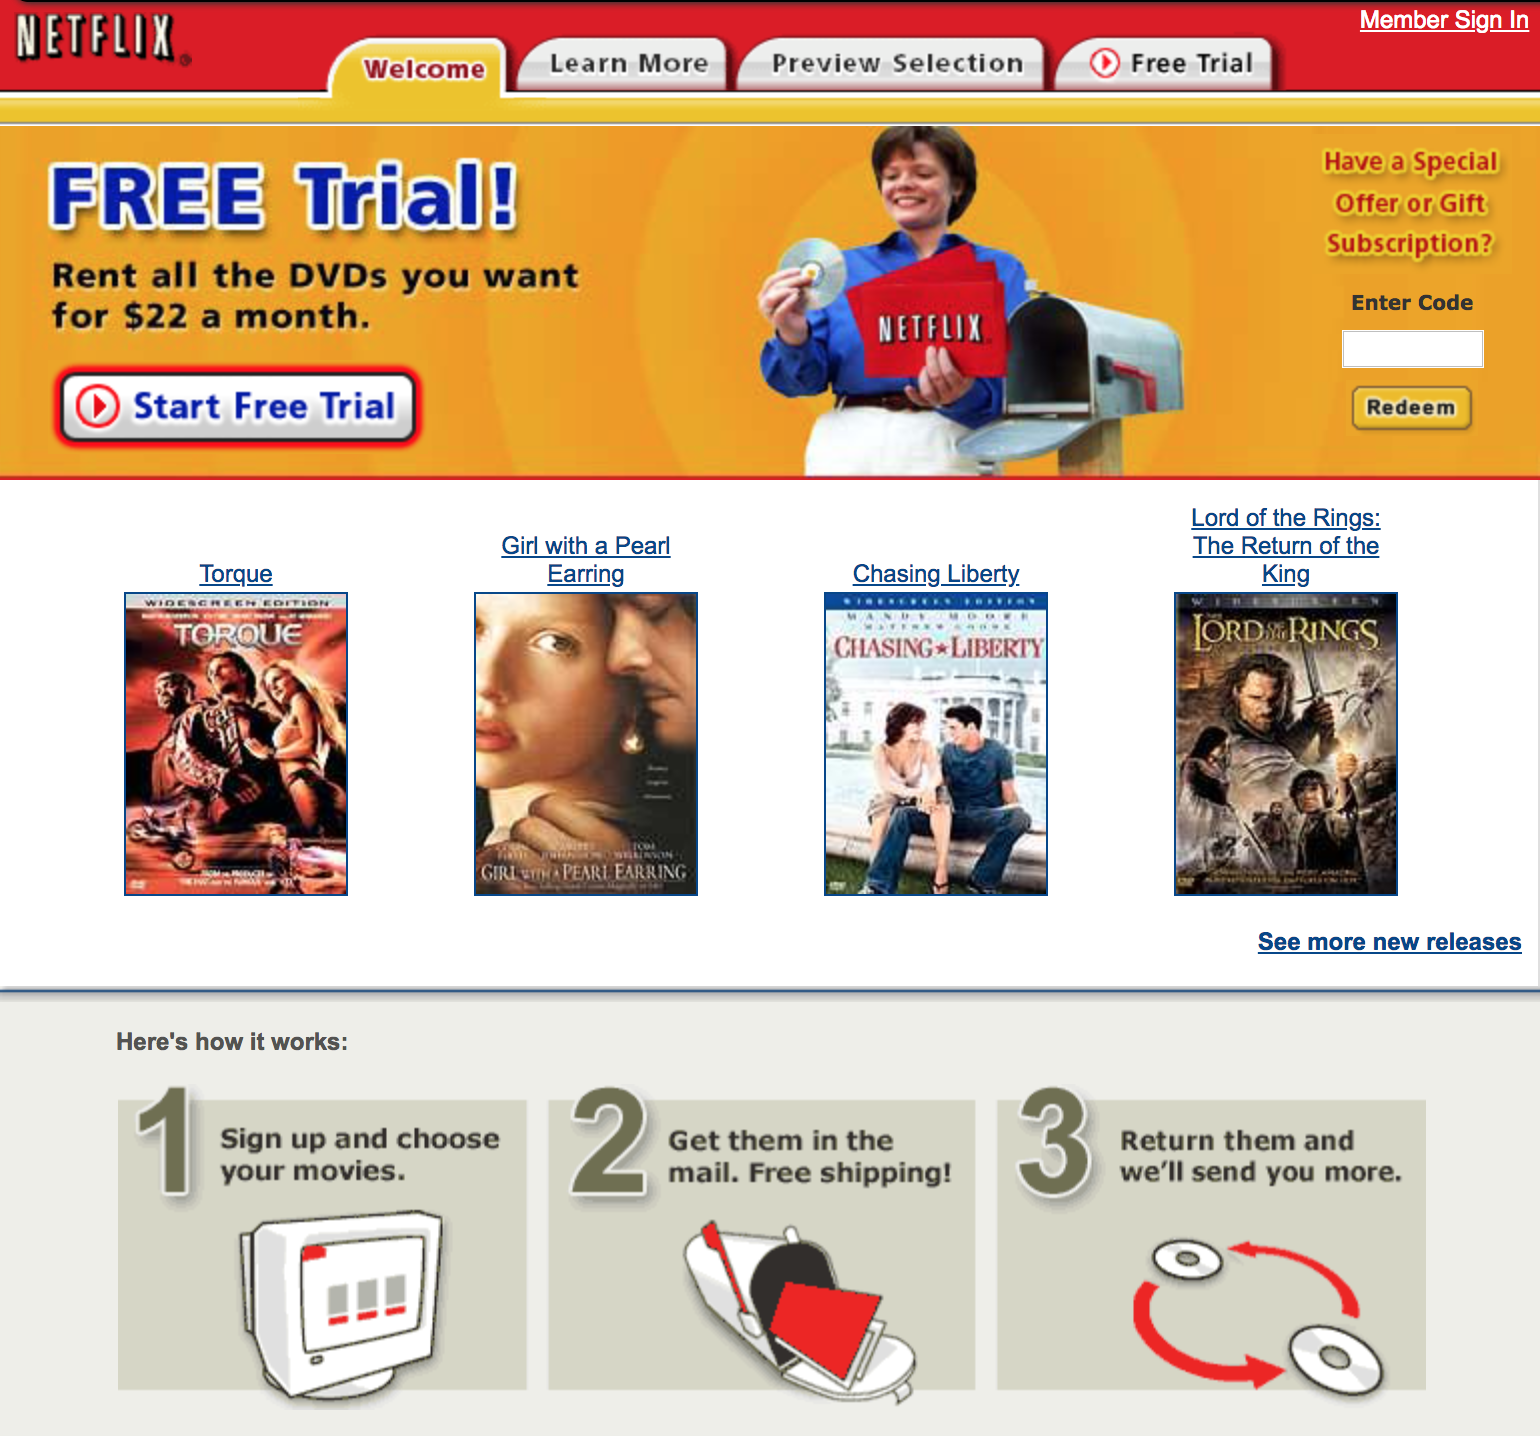

##Recommendation System (Content Based)

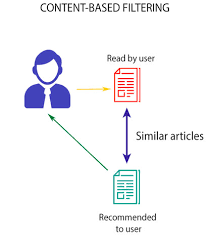

The TF-IDF(Term Frequency-Inverse Document Frequency (TF-IDF) ) score is the frequency of a word occurring in a document, down-weighted by the number of documents in which it occurs. This is done to reduce the importance of words that occur frequently in plot overviews and therefore, their significance in computing the final similarity score.

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [60]:
#removing stopwords
tfidf = TfidfVectorizer(stop_words='english')

#Replace NaN with an empty string
netflix_overall['description'] = netflix_overall['description'].fillna('')

#Construct the required TF-IDF matrix by fitting and transforming the data
tfidf_matrix = tfidf.fit_transform(netflix_overall['description'])

#Output the shape of tfidf_matrix
tfidf_matrix.shape

(8807, 18895)

There are about 16151 words described for the 6234 movies in this dataset.

Here, The Cosine similarity score is used since it is independent of magnitude and is relatively easy and fast to calculate.

In [61]:
# Import linear_kernel
from sklearn.metrics.pairwise import linear_kernel

# Compute the cosine similarity matrix
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [62]:
indices = pd.Series(netflix_overall.index, index=netflix_overall['title']).drop_duplicates()

In [63]:
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = indices[title]

    # Get the pairwsie similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return netflix_overall['title'].iloc[movie_indices]

This recommendation is just based on the Plot.

In [64]:
get_recommendations('Peaky Blinders')

,title
7683,Our Godfather
2646,My Stupid Boss
3133,Don
8293,The Fear
7140,Jonathan Strange & Mr Norrell
7785,Power Rangers Zeo
8467,The Prison
8539,The Tudors
1510,The Con Is On
8391,The Legend of Michael Mishra


In [65]:
get_recommendations('Mortel')

,title
256,Nneka The Pretty Serpent
3674,PILI Fantasy: War of Dragons
800,Mosquita y Mari
4511,Edgar Rice Burroughs' Tarzan and Jane
6749,Figures of Speech
7535,My Entire High School Sinking Into the Sea
6760,FirstBorn
4918,Psychokinesis
5481,Chamatkar
2190,The Umbrella Academy


##Content based filtering on the following factors:

Title
Cast
Director
Listed in
Plot

Filling null values with empty string.

In [66]:
filledna=netflix_overall.fillna('')
filledna.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


Cleaning the data - making all the words lower case

In [67]:
def clean_data(x):
        return str.lower(x.replace(" ", ""))

Identifying features on which the model is to be filtered.

In [68]:
features=['title','director','cast','listed_in','description']
filledna=filledna[features]

In [69]:
for feature in features:
    filledna[feature] = filledna[feature].apply(clean_data)

filledna.head(2)

,title,director,cast,listed_in,description
0,dickjohnsonisdead,kirstenjohnson,,documentaries,"asherfathernearstheendofhislife,filmmakerkirst..."
1,blood&water,,"amaqamata,khosingema,gailmabalane,thabangmolab...","internationaltvshows,tvdramas,tvmysteries","aftercrossingpathsataparty,acapetownteensetsou..."


Creating a "soup" or a "bag of words" for all rows.

In [70]:
def create_soup(x):
    return x['title']+ ' ' + x['director'] + ' ' + x['cast'] + ' ' +x['listed_in']+' '+ x['description']
filledna['soup'] = filledna.apply(create_soup, axis=1)

From here on, the code is basically similar to the upper model except the fact that count vectorizer is used instead of tfidf.

In [71]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(filledna['soup'])

cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

In [72]:
filledna=filledna.reset_index()
indices = pd.Series(filledna.index, index=filledna['title'])

In [73]:
def get_recommendations_new(title, cosine_sim=cosine_sim):
    title=title.replace(' ','').lower()
    idx = indices[title]

    # Get the pairwsie similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return netflix_overall['title'].iloc[movie_indices]

In [74]:
get_recommendations_new('PK', cosine_sim2)

,title
1114,3 Idiots
8391,The Legend of Michael Mishra
4790,Anthony Kaun Hai?
6907,Haapus
1022,Taare Zameen Par
4507,Sanju
2720,Dostana
4427,Chance Pe Dance
6439,Chal Dhar Pakad
195,EMI: Liya Hai To Chukana Padega


In [75]:
get_recommendations_new('Peaky Blinders', cosine_sim2)

,title
3034,Giri / Haji
5032,The Frankenstein Chronicles
8431,The Murder Detectives
4951,Loaded
4809,Kiss Me First
6922,Happy Valley
2184,Get Even
519,I AM A KILLER
3789,Killer Ratings
4476,Terrorism Close Calls


In [76]:
get_recommendations_new('The Hook Up Plan', cosine_sim2)

,title
2982,Find Yourself
1038,Dancing Angels
7438,Melodies of Life - Born This Way
3293,Little Things
6508,Club Friday To Be Continued - My Beautiful Tomboy
7872,Rishta.com
3463,College Romance
4171,The Perfect Match
4487,Accidentally in Love
5703,Refresh Man


##How many Netflix Shows/ Movies are made from books as their storylines?

In [77]:
!gdown 1UK-UCMWE0lWgWjImH12HIiLk_ub2ni5q
books=pd.read_csv('books.csv')
books['original_title']=books['original_title'].str.lower()
x=netflix_overall
x['title']=x['title'].str.lower()
t=x.merge(books, left_on='title', right_on='original_title', how="inner")

Downloading...
From: https://drive.google.com/uc?id=1UK-UCMWE0lWgWjImH12HIiLk_ub2ni5q
To: /content/books.csv
100% 3.30M/3.30M [00:00<00:00, 52.7MB/s]


In [78]:
t.head()

,show_id,type,title_x,director,cast,country,date_added,release_year,rating,duration,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,s42,Movie,jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,"September 16, 2021",1975,PG,124 min,...,102574,106201,2205,1836,5893,24737,35730,38005,https://images.gr-assets.com/books/1327958767m...,https://images.gr-assets.com/books/1327958767s...
1,s87,Movie,prey,Thomas Sieben,"David Kross, Hanno Koffler, Maria Ehrich, Robe...",NaN,"September 10, 2021",2021,TV-MA,87 min,...,131352,136307,2700,2481,11391,40947,48338,33150,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
2,s96,TV Show,the circle,NaN,Michelle Buteau,"United States, United Kingdom","September 8, 2021",2021,TV-MA,3 Seasons,...,109412,129023,17954,5667,16425,41080,44562,21289,https://images.gr-assets.com/books/1376419833m...,https://images.gr-assets.com/books/1376419833s...
3,s135,Movie,clear and present danger,Phillip Noyce,"Harrison Ford, Willem Dafoe, Anne Archer, Joaq...","United States, Mexico","September 1, 2021",1994,PG-13,142 min,...,105317,108638,574,973,3064,21463,44290,38848,https://images.gr-assets.com/books/1291440438m...,https://images.gr-assets.com/books/1291440438s...
4,s137,Movie,cold mountain,Anthony Minghella,"Jude Law, Nicole Kidman, Renée Zellweger, Eile...","United States, Italy, Romania, United Kingdom","September 1, 2021",2003,R,154 min,...,185979,190137,4884,6078,14021,43914,68143,57981,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...


In [79]:
t.shape

(339, 35)

In [80]:
import plotly.graph_objects as go

labels = ['Shows from books','Shows not from books']
values = [248,6234]

fig = go.Figure(data=[go.Pie(labels=labels, values=values)])
fig.show()

Hence, more accurate predictions are obtained.